In [1]:
#Load Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Group6_Cleaned_Dataset.csv")

print(df.head())

   listing_id                                              title  \
0     6527114         76 Ballinteer Drive, Ballinteer, Dublin 16   
1     6526314  43 Saint Ignatius Road, Dublin 7, Phibsborough...   
2     6526308  1 Donnybrook Close, Donnybrook, Dublin 4, D04X2W4   
3     6526132  Apartment 75, Bushy Park House, Templeogue Roa...   
4     6458414  21 Grosvenor Court, Dublin 6w, Templeogue, Dub...   

    property_type    price  beds  baths   eircode       area  \
0   Semi-Detached   595000     3      2  D16 R263  Dublin 16   
1  End of Terrace   425000     2      1   D07FW28   Dublin 7   
2   Semi-Detached  1450000     3      3   D04X2W4   Dublin 4   
3   Semi-Detached   515000     2      1   D12Y9Y9   Dublin 6   
4   Semi-Detached   695000     4      2   D24HK83   Dublin 6   

   distance_from_city_km distance_category  has_bus  has_dart  has_luas  \
0                     10             Outer        1         0         1   
1                     10             Outer        1     

In [2]:
#Basic Overview
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (991, 15)

Data Types:
 listing_id                int64
title                    object
property_type            object
price                     int64
beds                      int64
baths                     int64
eircode                  object
area                     object
distance_from_city_km     int64
distance_category        object
has_bus                   int64
has_dart                  int64
has_luas                  int64
url                      object
price_category           object
dtype: object

Missing Values:
 listing_id               0
title                    0
property_type            0
price                    0
beds                     0
baths                    0
eircode                  0
area                     0
distance_from_city_km    0
distance_category        0
has_bus                  0
has_dart                 0
has_luas                 0
url                      0
price_category           0
dtype: int64


In [3]:
#Summary 
print(df.describe())

         listing_id         price       beds       baths  \
count  9.910000e+02  9.910000e+02  991.00000  991.000000   
mean   6.344820e+06  6.918310e+05    2.87891    2.030272   
std    4.280808e+05  6.139109e+05    1.10347    1.066994   
min    4.898114e+06  1.800000e+05    1.00000    1.000000   
25%    6.472533e+06  3.750000e+05    2.00000    1.000000   
50%    6.506508e+06  4.950000e+05    3.00000    2.000000   
75%    6.521743e+06  7.500000e+05    3.00000    3.000000   
max    6.527829e+06  5.250000e+06    8.00000    8.000000   

       distance_from_city_km  has_bus    has_dart    has_luas  
count              991.00000    991.0  991.000000  991.000000  
mean                 8.19778      1.0    0.369324    0.449041  
std                  3.65663      0.0    0.482865    0.497648  
min                  1.00000      1.0    0.000000    0.000000  
25%                  5.00000      1.0    0.000000    0.000000  
50%                  7.00000      1.0    0.000000    0.000000  
75%        

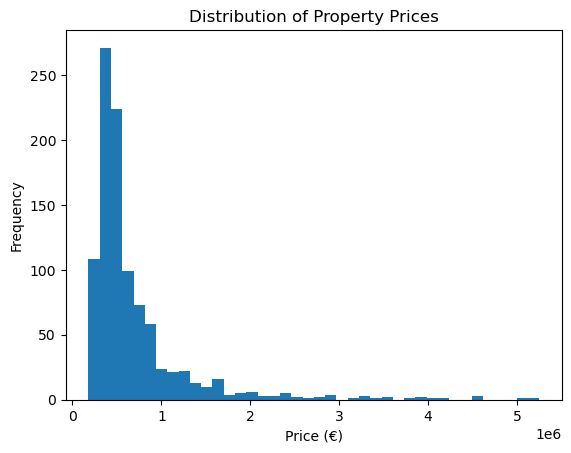

In [4]:
#Price Distribution
plt.figure()
plt.hist(df["price"], bins=40)
plt.title("Distribution of Property Prices")
plt.xlabel("Price (€)")
plt.ylabel("Frequency") #number of properties in each price range
plt.show()

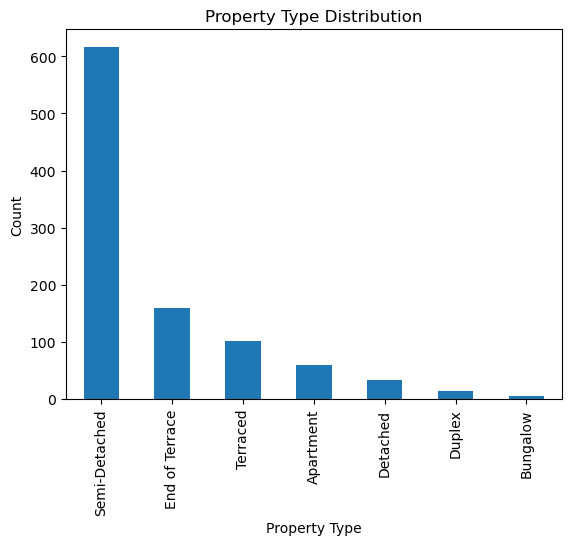

In [5]:
#property distibution
df["property_type"].value_counts().plot(kind="bar")
plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.show()

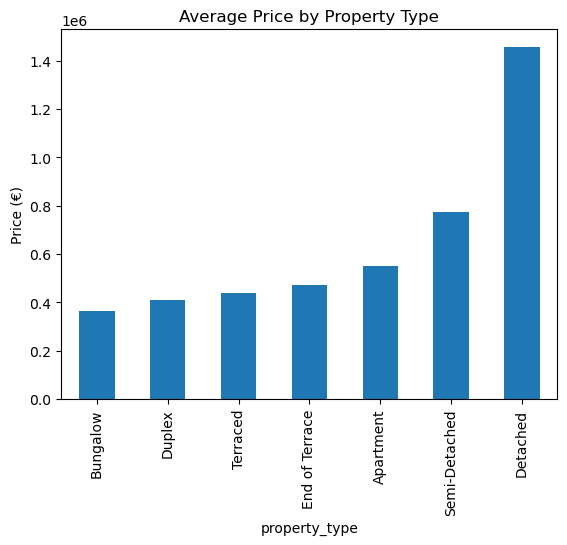

In [6]:
#Average price by Property Type
df.groupby("property_type")["price"].mean().sort_values().plot(kind="bar")
plt.title("Average Price by Property Type")
plt.ylabel("Price (€)")
plt.show()

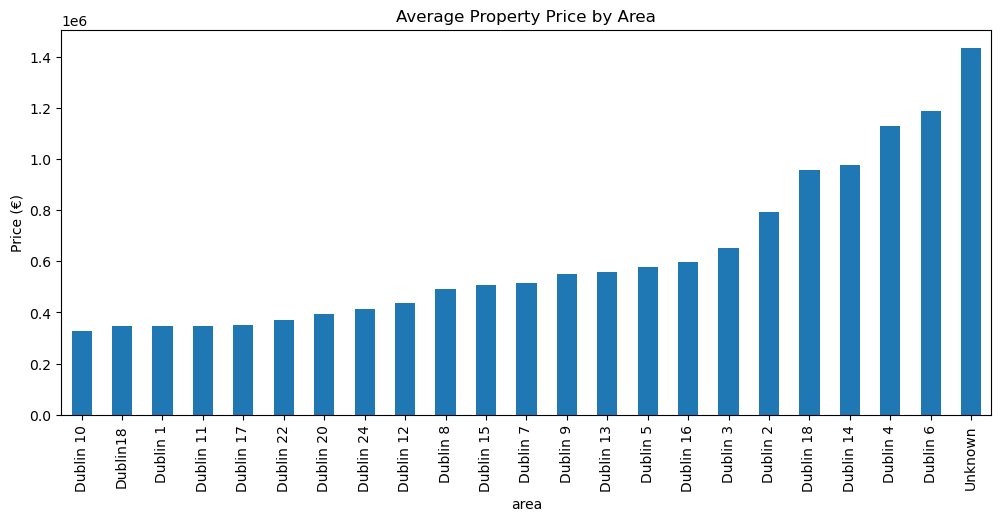

In [7]:
#Average price by area
area_price = df.groupby("area")["price"].mean().sort_values()

area_price.plot(kind="bar", figsize=(12,5))
plt.title("Average Property Price by Area")
plt.ylabel("Price (€)")
plt.show()

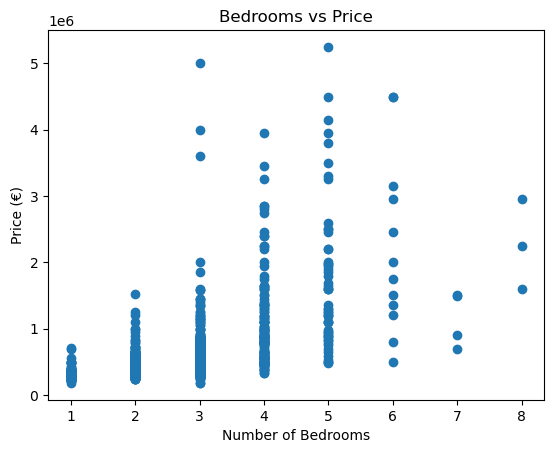

In [12]:
#beds vs price
plt.figure()
plt.scatter(df["beds"], df["price"])
plt.title("Bedrooms vs Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (€)")
plt.show()

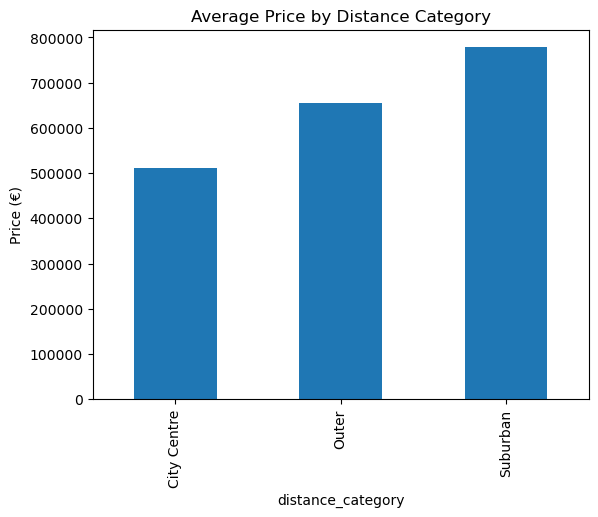

In [13]:
#price by distance category
df.groupby("distance_category")["price"].mean().plot(kind="bar")
plt.title("Average Price by Distance Category")
plt.ylabel("Price (€)")
plt.show()

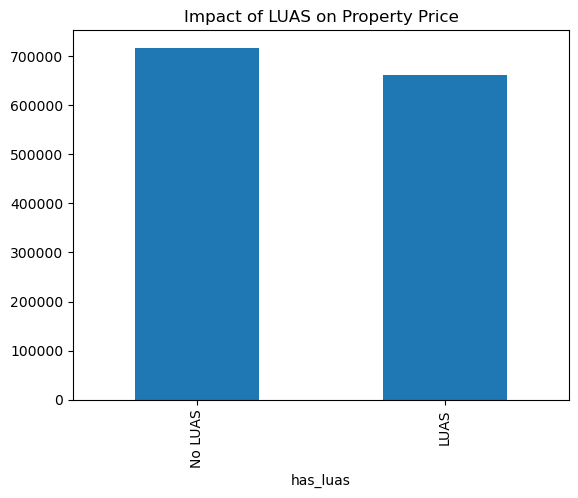

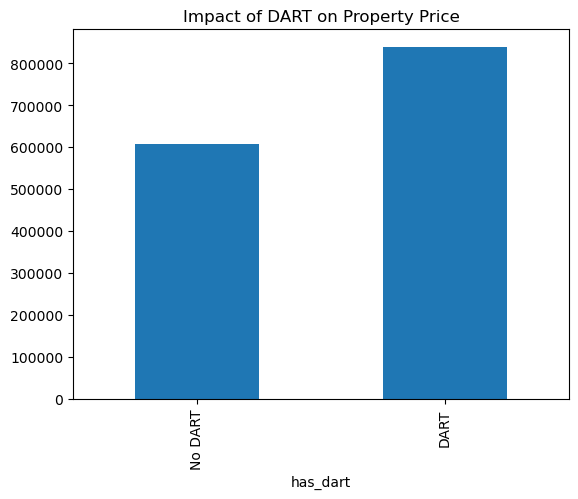

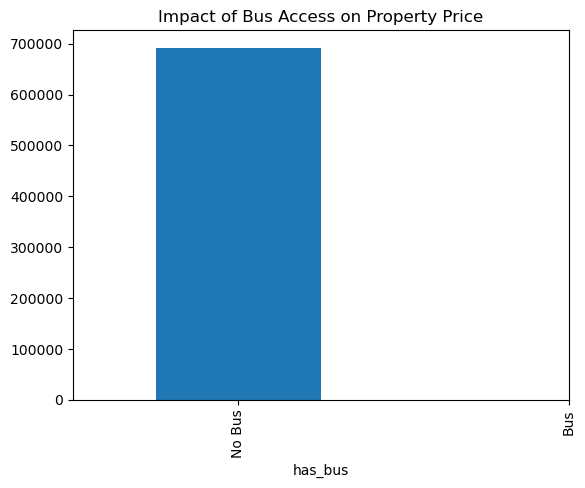

In [14]:
#transport Imapct Analysis
# LUAS
df.groupby("has_luas")["price"].mean().plot(kind="bar")
plt.title("Impact of LUAS on Property Price")
plt.xticks([0,1], ["No LUAS", "LUAS"])
plt.show()

# DART
df.groupby("has_dart")["price"].mean().plot(kind="bar")
plt.title("Impact of DART on Property Price")
plt.xticks([0,1], ["No DART", "DART"])
plt.show()

# BUS
df.groupby("has_bus")["price"].mean().plot(kind="bar")
plt.title("Impact of Bus Access on Property Price")
plt.xticks([0,1], ["No Bus", "Bus"])
plt.show()

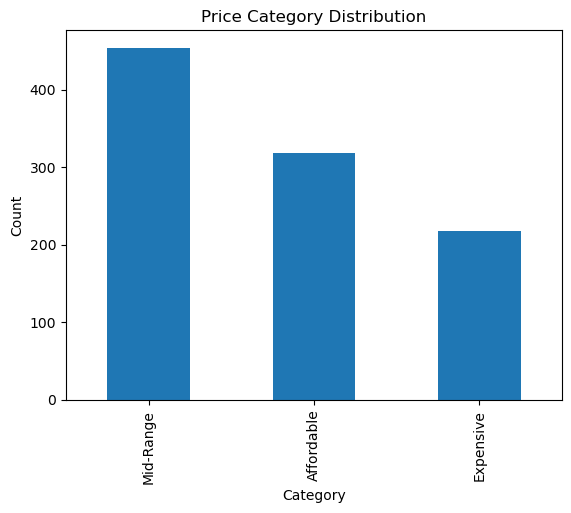

In [15]:
#Price category distribution
df["price_category"].value_counts().plot(kind="bar")
plt.title("Price Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

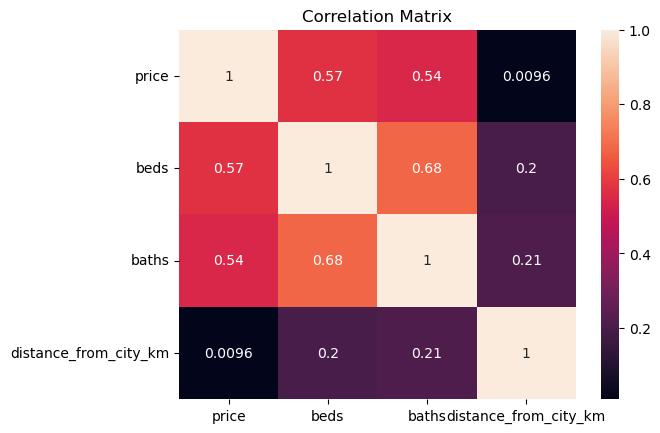

In [16]:
#Corealation Heat map
plt.figure()
sns.heatmap(df[["price","beds","baths","distance_from_city_km"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()